# Worksheet Summary: Multiple Linear Regression via Normal Equation

This notebook demonstrates the manual implementation of **Multiple Linear Regression** to predict house prices using features like square footage and age.

### Key Steps Taken:
*   **Data Preparation**: Created a synthetic dataset of house prices ($y$) based on square footage ($x_1$) and age ($x_2$).
*   **Feature Matrix Construction ($X$)**: Built a 2D matrix including a 'Column of 1s' to account for the model's intercept (bias).
*   **Mathematical Implementation**: Solved for the optimal coefficient vector ($\beta$) using the **Normal Equation**:  
    $$\beta = (X^T X)^{-1} X^T y$$
*   **Coefficient Analysis**: Extracted weights for each feature, showing how square footage positively impacts price while age negatively impacts it.
*   **Visualizations**:
    *   **Matrix Representation**: Displayed the raw data structure using Pandas for clarity.
    *   **3D Regression Plane**: Rendered a 3D plot showing the relationship between features and the line of best fit relative to actual data points.

In [1]:
import numpy as np

# 1. Create Sample Data (e.g., predicting House Price)
# Feature 1: Square Footage (x1)
# Feature 2: Age of House in Years (x2)
x1 = np.array([1200, 1500, 1700, 2000, 2200])
x2 = np.array([10, 5, 2, 15, 8])

# Target: Price in thousands of dollars (y)
y = np.array([250, 320, 360, 400, 450])

# 2. Build the Feature Matrix (X)
# CRITICAL STEP: We must add a column of 1s to act as a placeholder for our y-intercept (Beta_0)
ones = np.ones(len(x1))

# np.column_stack takes our 1D arrays and stands them up side-by-side into a 2D matrix
X = np.column_stack((ones, x1, x2))

# 3. The Normal Equation
# In NumPy: '.T' gives the transpose, '@' multiplies matrices, 'np.linalg.inv' finds the inverse

# Step A: X transpose
X_transpose = X.T

# Step B: (X^T * X)
X_T_X = X_transpose @ X

# Step C: Inverse of (X^T * X)
X_T_X_inv = np.linalg.inv(X_T_X)

# Step D: (X^T * Y)
X_T_Y = X_transpose @ y

# Step E: Multiply the inverse matrix by the (X^T * Y) matrix
beta_vector = X_T_X_inv @ X_T_Y

# 4. Extract and print the calculated coefficients
intercept = beta_vector[0]
slope_1 = beta_vector[1]
slope_2 = beta_vector[2]

print("--- Calculated Coefficients ---")
print(f"Intercept (Beta_0): {intercept:.4f}")
print(f"Square Foot Weight (Beta_1): {slope_1:.4f}")
print(f"Age Weight (Beta_2): {slope_2:.4f}")

print(f"\nFinal Equation: y = {intercept:.4f} + ({slope_1:.4f} * x1) + ({slope_2:.4f} * x2)")

--- Calculated Coefficients ---
Intercept (Beta_0): 31.4666
Square Foot Weight (Beta_1): 0.1959
Age Weight (Beta_2): -1.5624

Final Equation: y = 31.4666 + (0.1959 * x1) + (-1.5624 * x2)


In [2]:
import pandas as pd

# Representing the Feature Matrix X as a DataFrame for better visualization
feature_names = ['Intercept (1s)', 'Square Footage (x1)', 'Age (x2)']
X_df = pd.DataFrame(X, columns=feature_names)

print("Matrix X Structure (First 5 rows):")
display(X_df)

print("\nBeta Vector (Coefficients):")
beta_df = pd.DataFrame(beta_vector, index=feature_names, columns=['Value'])
display(beta_df)

Matrix X Structure (First 5 rows):


,Intercept (1s),Square Footage (x1),Age (x2)
0,1.0,1200.0,10.0
1,1.0,1500.0,5.0
2,1.0,1700.0,2.0
3,1.0,2000.0,15.0
4,1.0,2200.0,8.0



Beta Vector (Coefficients):


,Value
Intercept (1s),31.466567
Square Footage (x1),0.195949
Age (x2),-1.562383


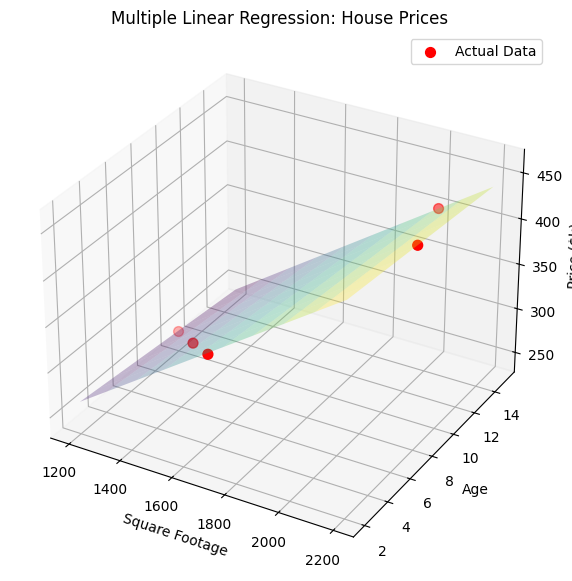

In [3]:

'''GENERATED BY AI JUST FOR EXPLANATION AND IS NOT DONE BY THE AUTHOR , ONLY TO
BE VISUALIZED'''

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a meshgrid for the plane
x1_range = np.linspace(x1.min(), x1.max(), 10)
x2_range = np.linspace(x2.min(), x2.max(), 10)
X1, X2 = np.meshgrid(x1_range, x2_range)

# Calculate the predicted Y values for the plane
Y_pred = intercept + (slope_1 * X1) + (slope_2 * X2)

# Plotting
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of actual data points
ax.scatter(x1, x2, y, color='red', s=50, label='Actual Data')

# Plot the regression plane
surf = ax.plot_surface(X1, X2, Y_pred, alpha=0.3, cmap='viridis')

ax.set_xlabel('Square Footage')
ax.set_ylabel('Age')
ax.set_zlabel('Price ($k)')
ax.set_title('Multiple Linear Regression: House Prices')
plt.legend()
plt.show()